# Fisheye Optical Center and Effective Radius Estimation\n
\n
This notebook estimates the optical center `(cx, cy)` and effective imaging radius `r` from raw fisheye images by fitting a circle to the valid image region.\n
\n
Workflow:\n
1. Read a subset of images from a folder recursively.\n
2. Segment the valid (non-black) fisheye region.\n
3. Fit a circle on the region boundary for each image.\n
4. Use robust aggregation (median + MAD filtering) to get final `(cx, cy, r)`.\n
5. Save results and visualize overlays.\n

In [6]:
from pathlib import Path
import json
import tarfile
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# ===== Config =====
IMAGE_ROOT = Path('2019StanFord_image')
GLOB_PATTERNS = ['**/*.jpg', '**/*.jpeg', '**/*.png', '**/*.bmp']
TAR_PATTERNS = ['*.tar']
MAX_IMAGES = 400
BLACK_THRESHOLD = 8
MIN_COMPONENT_AREA_RATIO = 0.15
VIS_SAMPLES = 8
RANDOM_SEED = 42

OUTPUT_JSON = Path('output_folder/fisheye_center_radius.json')
OUTPUT_NPY = Path('output_folder/fisheye_center_radius.npy')

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [8]:
def collect_image_paths(root: Path, patterns):
    paths = []
    for p in patterns:
        paths.extend(root.glob(p))
    paths = sorted(set(paths))
    return [p for p in paths if p.is_file()]


def collect_tar_members(root: Path, tar_patterns, image_suffixes=None):
    if image_suffixes is None:
        image_suffixes = ('.jpg', '.jpeg', '.png', '.bmp')

    tar_paths = []
    for p in tar_patterns:
        tar_paths.extend(root.glob(p))
    tar_paths = sorted(set([p for p in tar_paths if p.is_file()]))

    members = []
    for tar_path in tar_paths:
        try:
            with tarfile.open(tar_path, 'r') as tar:
                for m in tar.getmembers():
                    if not m.isfile():
                        continue
                    name_l = m.name.lower()
                    if name_l.endswith(image_suffixes):
                        members.append((tar_path, m.name))
        except Exception as e:
            print(f'Warning: skip broken tar {tar_path}, err={e}')

    return members


def sample_paths(paths, max_images):
    if len(paths) <= max_images:
        return paths
    idx = np.linspace(0, len(paths) - 1, max_images).astype(int)
    return [paths[i] for i in idx]


def keep_largest_component(binary_mask: np.ndarray):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    if num_labels <= 1:
        return None
    largest_id = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    out = (labels == largest_id).astype(np.uint8) * 255
    return out


def fit_circle_least_squares(points_xy: np.ndarray):
    # Solve x^2 + y^2 + A x + B y + C = 0 in least-squares sense
    x = points_xy[:, 0].astype(np.float64)
    y = points_xy[:, 1].astype(np.float64)
    M = np.column_stack([x, y, np.ones_like(x)])
    b = -(x**2 + y**2)
    params, _, _, _ = np.linalg.lstsq(M, b, rcond=None)
    A, B, C = params
    cx = -A / 2.0
    cy = -B / 2.0
    r_sq = (A * A + B * B) / 4.0 - C
    if r_sq <= 0:
        raise ValueError('Invalid fitted radius squared.')
    r = np.sqrt(r_sq)
    return cx, cy, r


def read_image_from_source(src):
    if isinstance(src, Path):
        return cv2.imread(str(src), cv2.IMREAD_COLOR), str(src)

    tar_path, member_name = src
    try:
        with tarfile.open(tar_path, 'r') as tar:
            f = tar.extractfile(member_name)
            if f is None:
                return None, f'{tar_path}::{member_name}'
            buf = np.frombuffer(f.read(), dtype=np.uint8)
            img = cv2.imdecode(buf, cv2.IMREAD_COLOR)
            return img, f'{tar_path}::{member_name}'
    except Exception:
        return None, f'{tar_path}::{member_name}'


def estimate_circle_from_image(image_bgr: np.ndarray, black_threshold=8, min_area_ratio=0.15):
    h, w = image_bgr.shape[:2]
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Segment non-black region (valid fisheye area)
    binary = (gray > black_threshold).astype(np.uint8) * 255
    kernel = np.ones((5, 5), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

    largest = keep_largest_component(binary)
    if largest is None:
        return None

    area = int(np.count_nonzero(largest))
    if area < int(h * w * min_area_ratio):
        return None

    contours, _ = cv2.findContours(largest, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None

    c = max(contours, key=cv2.contourArea)
    pts = c.reshape(-1, 2)
    if len(pts) < 20:
        return None

    cx, cy, r = fit_circle_least_squares(pts)
    return {
        'cx': float(cx),
        'cy': float(cy),
        'r': float(r),
        'area': area,
        'mask': largest
    }

In [9]:
all_paths = collect_image_paths(IMAGE_ROOT, GLOB_PATTERNS)
all_tar_members = collect_tar_members(IMAGE_ROOT, TAR_PATTERNS)

if len(all_paths) > 0:
    source_kind = 'image_files'
    source_all = all_paths
else:
    source_kind = 'tar_members'
    source_all = all_tar_members

use_paths = sample_paths(source_all, MAX_IMAGES)

print(f'Source kind  : {source_kind}')
print(f'Found sources: {len(source_all)}')
print(f'Using sources: {len(use_paths)}')
if len(use_paths) == 0:
    raise RuntimeError('No image source found. Please check IMAGE_ROOT.')

Source kind  : tar_members
Found sources: 146296
Using sources: 400


In [10]:
records = []
failed = []

for src in use_paths:
    img, src_name = read_image_from_source(src)
    if img is None:
        failed.append((src_name, 'imread_failed'))
        continue

    est = estimate_circle_from_image(
        img,
        black_threshold=BLACK_THRESHOLD,
        min_area_ratio=MIN_COMPONENT_AREA_RATIO,
    )

    if est is None:
        failed.append((src_name, 'fit_failed'))
        continue

    records.append({
        'path': src_name,
        'cx': est['cx'],
        'cy': est['cy'],
        'r': est['r'],
        'area': est['area'],
    })

print(f'Success: {len(records)}, Failed: {len(failed)}')
if len(records) < 5:
    raise RuntimeError('Too few successful fits. Try lowering BLACK_THRESHOLD or MIN_COMPONENT_AREA_RATIO.')

Success: 388, Failed: 12


In [11]:
arr = np.array([[r['cx'], r['cy'], r['r']] for r in records], dtype=np.float64)
med = np.median(arr, axis=0)
mad = np.median(np.abs(arr - med), axis=0)
scale = 1.4826 * mad + 1e-9
z = np.abs((arr - med) / scale)
inlier_mask = np.all(z < 3.5, axis=1)
inliers = arr[inlier_mask]

if len(inliers) < 5:
    raise RuntimeError('Too few inliers after robust filtering.')

cx_final, cy_final, r_final = np.median(inliers, axis=0)
cx_std, cy_std, r_std = np.std(inliers, axis=0)

print('Final estimate (median of inliers):')
print(f'  cx = {cx_final:.3f} +/- {cx_std:.3f}')
print(f'  cy = {cy_final:.3f} +/- {cy_std:.3f}')
print(f'  r  = {r_final:.3f} +/- {r_std:.3f}')
print(f'Inliers: {len(inliers)} / {len(arr)}')

Final estimate (median of inliers):
  cx = 1053.561 +/- 0.280
  cy = 1024.622 +/- 0.175
  r  = 1017.189 +/- 0.221
Inliers: 255 / 388


In [12]:
OUTPUT_JSON.parent.mkdir(parents=True, exist_ok=True)

result = {
    'cx': float(cx_final),
    'cy': float(cy_final),
    'r': float(r_final),
    'cx_std': float(cx_std),
    'cy_std': float(cy_std),
    'r_std': float(r_std),
    'num_total': int(len(arr)),
    'num_inliers': int(len(inliers)),
    'image_root': str(IMAGE_ROOT),
    'black_threshold': int(BLACK_THRESHOLD),
    'min_component_area_ratio': float(MIN_COMPONENT_AREA_RATIO),
}

with open(OUTPUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(result, f, indent=2)

np.save(OUTPUT_NPY, np.array([cx_final, cy_final, r_final], dtype=np.float64))

print(f'Saved json: {OUTPUT_JSON}')
print(f'Saved npy : {OUTPUT_NPY}')

Saved json: output_folder\fisheye_center_radius.json
Saved npy : output_folder\fisheye_center_radius.npy


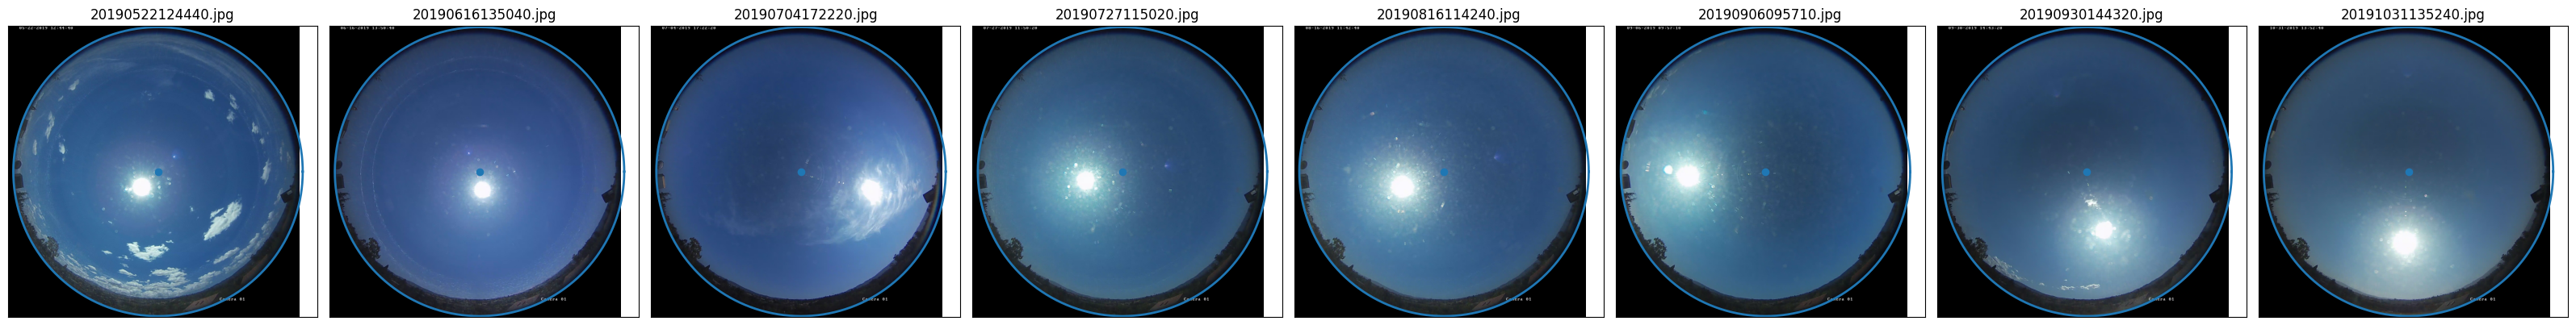

In [13]:
# Visualization of several inlier samples
inlier_records = [records[i] for i in np.where(inlier_mask)[0]]
vis_n = min(VIS_SAMPLES, len(inlier_records))
vis_idx = np.linspace(0, len(inlier_records) - 1, vis_n).astype(int)

fig, axes = plt.subplots(1, vis_n, figsize=(4 * vis_n, 4))
if vis_n == 1:
    axes = [axes]

for ax, i in zip(axes, vis_idx):
    rec = inlier_records[i]
    src_name = rec['path']

    if '::' in src_name:
        tar_path, member_name = src_name.split('::', 1)
        img, _ = read_image_from_source((Path(tar_path), member_name))
        title_name = Path(member_name).name
    else:
        img, _ = read_image_from_source(Path(src_name))
        title_name = Path(src_name).name

    if img is None:
        ax.set_title(f'failed: {title_name}')
        ax.axis('off')
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    t = np.linspace(0, 2 * np.pi, 800)
    x = cx_final + r_final * np.cos(t)
    y = cy_final + r_final * np.sin(t)
    ax.plot(x, y, linewidth=2)
    ax.scatter([cx_final], [cy_final], s=35)

    ax.set_title(title_name)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()